In [1]:
# import libraries
import pandas as pd
import numpy as np

In [2]:
# upload the Excel file
from google.colab import files
uploaded = files.upload()

Saving Agriculture_Crop_Cost_Profitability_2022_2025_v2.xlsx to Agriculture_Crop_Cost_Profitability_2022_2025_v2.xlsx


In [3]:
# loding all sheets from dataset file

crop_master = pd.read_excel("Agriculture_Crop_Cost_Profitability_2022_2025_v2.xlsx", sheet_name="Crop_Master")

farm_region = pd.read_excel("Agriculture_Crop_Cost_Profitability_2022_2025_v2.xlsx", sheet_name="Farm_Region")

date_table = pd.read_excel("Agriculture_Crop_Cost_Profitability_2022_2025_v2.xlsx", sheet_name="Date_Table")

cost_details = pd.read_excel("Agriculture_Crop_Cost_Profitability_2022_2025_v2.xlsx", sheet_name="Cost_Details")

production_sales = pd.read_excel("Agriculture_Crop_Cost_Profitability_2022_2025_v2.xlsx", sheet_name="Production_Sales")

In [4]:
crop_master.head()

,Crop_ID,Crop_Name,Crop_Category,Season,Avg_Growth_Days
0,C01,Rice,Cereal,Kharif,120
1,C02,Wheat,Cereal,Rabi,135
2,C03,Maize,Cereal,Kharif,100
3,C04,Mustard,Oilseed,Rabi,110
4,C05,Potato,Vegetable,Rabi,90


In [5]:
farm_region.head()

,Farm_ID,Farm_Name,Region,Farmer_Type
0,F01,GreenGrow Farm,North WB,Medium
1,F02,AgriLife Farm,South WB,Small
2,F03,CropMax Farm,North WB,Large
3,F04,Sunrise Agro,Central WB,Medium
4,F05,FieldFresh Farm,South WB,Small


In [6]:
date_table.head()

,Date,Year,Month Number,Month Name,Quarter,Year-Month,Day,Weekday
0,2022-01-01,2022,1,January,Q1,2022-01,1,Saturday
1,2022-01-02,2022,1,January,Q1,2022-01,2,Sunday
2,2022-01-03,2022,1,January,Q1,2022-01,3,Monday
3,2022-01-04,2022,1,January,Q1,2022-01,4,Tuesday
4,2022-01-05,2022,1,January,Q1,2022-01,5,Wednesday


In [7]:
cost_details.head()

,Date,Crop_ID,Farm_ID,Cost_Category,Cost_Amount,Acreage
0,2022-06-01,C01,F01,Seed,8000,5
1,2022-06-01,C01,F01,Fertilizer,15000,5
2,2022-06-01,C01,F01,Labor,12000,5
3,2022-06-01,C01,F01,Water,7000,5
4,2022-06-01,C01,F01,Pesticide,5000,5


In [8]:
production_sales.head()

,Date,Crop_ID,Farm_ID,Production_Qty,Selling_Price_per_Qtl,Total_Revenue
0,2022-10-01,C01,F01,120,2200,264000
1,2022-10-01,C02,F02,95,2400,228000
2,2022-10-01,C03,F03,110,2100,231000
3,2022-10-01,C04,F04,80,2600,208000
4,2022-10-01,C05,F05,140,1800,252000


In [9]:
# dataset shape
print (crop_master.shape)
print (farm_region.shape)
print (cost_details.shape)
print (date_table.shape)
print (production_sales.shape)

(5, 5)
(5, 4)
(100, 6)
(1461, 8)
(20, 6)


## **merge the tables**



In [10]:
data = pd.merge(cost_details,production_sales,on=["Date","Crop_ID","Farm_ID"],how="left")

In [11]:
#adding crop details
data = pd.merge(data,crop_master,on="Crop_ID",how="left")

In [12]:
#adding farm details
data = pd.merge(data,farm_region,on="Farm_ID",how="left")

In [13]:
data.head()

,Date,Crop_ID,Farm_ID,Cost_Category,Cost_Amount,Acreage,Production_Qty,Selling_Price_per_Qtl,Total_Revenue,Crop_Name,Crop_Category,Season,Avg_Growth_Days,Farm_Name,Region,Farmer_Type
0,2022-06-01,C01,F01,Seed,8000,5,NaN,NaN,NaN,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
1,2022-06-01,C01,F01,Fertilizer,15000,5,NaN,NaN,NaN,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
2,2022-06-01,C01,F01,Labor,12000,5,NaN,NaN,NaN,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
3,2022-06-01,C01,F01,Water,7000,5,NaN,NaN,NaN,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
4,2022-06-01,C01,F01,Pesticide,5000,5,NaN,NaN,NaN,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium


In [14]:
# dataset(data) shape
data.shape

(100, 16)

## **create pivot table**

In [15]:
cost_pivot = cost_details.pivot_table(index=["Date","Crop_ID","Farm_ID"],columns="Cost_Category",values="Cost_Amount",aggfunc="sum").reset_index()

In [16]:
cost_pivot.head()

Cost_Category,Date,Crop_ID,Farm_ID,Fertilizer,Labor,Pesticide,Seed,Water
0,2022-06-01,C01,F01,15000,12000,5000,8000,7000
1,2022-06-01,C02,F02,15000,12000,5000,8000,7000
2,2022-06-01,C03,F03,15000,12000,5000,8000,7000
3,2022-06-01,C04,F04,15000,12000,5000,8000,7000
4,2022-06-01,C05,F05,15000,12000,5000,8000,7000


In [17]:
# replace missing value in table
cost_pivot=cost_pivot.fillna(0)

In [18]:
#table shape
cost_pivot.shape

(20, 8)

### **merge pivot cost with production data**

In [19]:
model_data = pd.merge(cost_pivot,production_sales,on=["Crop_ID","Farm_ID"],how="left")

In [20]:
#adding crop information
model_data = pd.merge(model_data,crop_master,on="Crop_ID",how="left")

In [21]:
#adding farm information
model_data = pd.merge(model_data,farm_region,on="Farm_ID",how="left")

In [22]:
model_data.head()

,Date_x,Crop_ID,Farm_ID,Fertilizer,Labor,Pesticide,Seed,Water,Date_y,Production_Qty,Selling_Price_per_Qtl,Total_Revenue,Crop_Name,Crop_Category,Season,Avg_Growth_Days,Farm_Name,Region,Farmer_Type
0,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2022-10-01,120,2200,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
1,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2023-10-01,120,2200,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
2,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2024-10-01,120,2200,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
3,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2025-10-01,120,2200,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium
4,2022-06-01,C02,F02,15000,12000,5000,8000,7000,2022-10-01,95,2400,228000,Wheat,Cereal,Rabi,135,AgriLife Farm,South WB,Small


In [23]:
# ceateing total cost
model_data["Total_cost"]=(model_data["Seed"] + model_data["Fertilizer"] + model_data["Labor"] +
                          model_data["Water"] + model_data["Pesticide"])

In [24]:
# creating profit
model_data["Profit"]=(model_data["Total_Revenue"] - model_data["Total_cost"])

In [25]:
#model data head
model_data.head()

,Date_x,Crop_ID,Farm_ID,Fertilizer,Labor,Pesticide,Seed,Water,Date_y,Production_Qty,...,Total_Revenue,Crop_Name,Crop_Category,Season,Avg_Growth_Days,Farm_Name,Region,Farmer_Type,Total_cost,Profit
0,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2022-10-01,120,...,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium,47000,217000
1,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2023-10-01,120,...,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium,47000,217000
2,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2024-10-01,120,...,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium,47000,217000
3,2022-06-01,C01,F01,15000,12000,5000,8000,7000,2025-10-01,120,...,264000,Rice,Cereal,Kharif,120,GreenGrow Farm,North WB,Medium,47000,217000
4,2022-06-01,C02,F02,15000,12000,5000,8000,7000,2022-10-01,95,...,228000,Wheat,Cereal,Rabi,135,AgriLife Farm,South WB,Small,47000,181000


In [26]:
model_data.columns

Index(['Date_x', 'Crop_ID', 'Farm_ID', 'Fertilizer', 'Labor', 'Pesticide',
       'Seed', 'Water', 'Date_y', 'Production_Qty', 'Selling_Price_per_Qtl',
       'Total_Revenue', 'Crop_Name', 'Crop_Category', 'Season',
       'Avg_Growth_Days', 'Farm_Name', 'Region', 'Farmer_Type', 'Total_cost',
       'Profit'],
      dtype='object')

## **selecting features and target**

In [27]:
y=model_data["Profit"]
x=model_data[["Seed","Fertilizer","Labor","Water","Pesticide","Production_Qty","Avg_Growth_Days","Selling_Price_per_Qtl"]]

In [28]:
# looking for missing values
x=x.fillna(0)
y=y.fillna(0)

### **train test split**

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
#chack shapes
print(x_train.shape)
print(x_test.shape)

(64, 8)
(16, 8)


## **model building**

### **linear regression**

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#creating model
model=LinearRegression()

#train model
model.fit(x_train,y_train)

#prediction
y_pred=model.predict(x_test)

#evaluation
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [32]:
print("mean absolute error:",mae)
print("r2 score:",r2)

#prediction head
print("\n sample prediction:")
print(y_pred[:5])

mean absolute error: 4848.569704889971
r2 score: 0.9074592965303172

 sample prediction:
[171538.27338017 213489.4727944  208428.50910413 171538.27338017
 208935.56297099]


### **random forest**

In [33]:
from sklearn.ensemble import RandomForestRegressor

# creating model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# train model
rf_model.fit(x_train, y_train)

# prediction
y_pred_rf = rf_model.predict(x_test)

# evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("random forest model performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

random forest model performance
MAE: 389.375
RMSE: 520.3064001143941
R2 Score: 0.9991466285770576


In [34]:
#prediction head of random forest
print("sample prediction:")
print(y_pred_rf[:5])

sample prediction:
[178040. 216650. 212000. 178040. 204800.]


In [35]:
# model comparison table
model_comparison = pd.DataFrame({"model":["linear regression","random forest"],
                                 "R2 score":[r2,r2_rf],
                                 "MAE":[mae,mae_rf],})
print(model_comparison)

               model  R2 score          MAE
0  linear regression  0.907459  4848.569705
1      random forest  0.999147   389.375000


## **feature imoprtance**

In [36]:
import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

                 Feature  Importance
5         Production_Qty    0.824668
7  Selling_Price_per_Qtl    0.093240
0                   Seed    0.014949
2                  Labor    0.014573
1             Fertilizer    0.014113
4              Pesticide    0.013387
6        Avg_Growth_Days    0.012874
3                  Water    0.012195


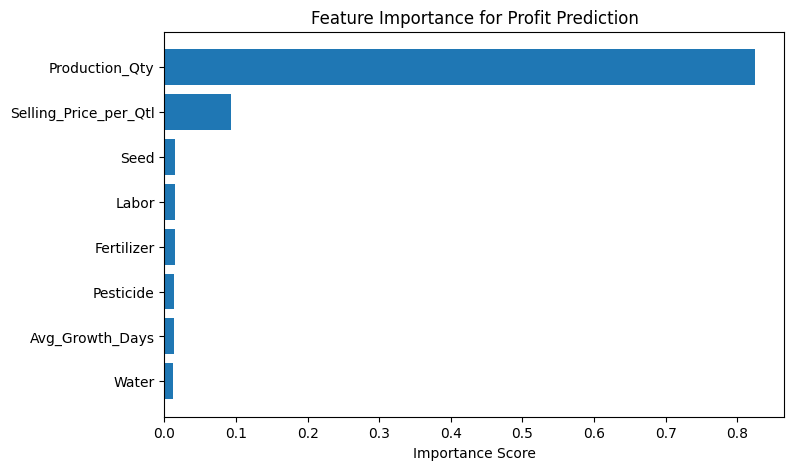

In [37]:
# graph
plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance for Profit Prediction")
plt.gca().invert_yaxis()
plt.show()

In [84]:
# creating 2026 dataset
forecast_2026 = x.copy()

In [85]:
# importing some important columns from model_data
forecast_2026["Crop_ID"] = model_data["Crop_ID"]
forecast_2026["Farm_ID"] = model_data["Farm_ID"]
forecast_2026["Crop_Name"] = model_data["Crop_Name"]
forecast_2026["Farm_Name"] = model_data["Farm_Name"]

In [86]:
season_map = {
    "Rice": "Kharif",
    "Maize": "Kharif",
    "Mustard": "Rabi",
    "Wheat": "Rabi",
    "Potato": "Rabi"
}

forecast_2026["season"] = forecast_2026["Crop_Name"].map(season_map)

In [87]:
# creating forcast dates
season_date_map = {
    "Kharif": "2026-06-01",
    "Rabi": "2026-10-01"
}

forecast_2026["Forecast_Date"] = forecast_2026["season"].map(season_date_map)

forecast_2026["Forecast_Date"] = pd.to_datetime(forecast_2026["Forecast_Date"])

In [88]:
# create forcast cost for 2026
forecast_2026["Predicted_Cost"] = (
    forecast_2026["Seed"] +
    forecast_2026["Fertilizer"] +
    forecast_2026["Labor"] +
    forecast_2026["Water"] +
    forecast_2026["Pesticide"]
)

In [89]:
# predective profint for 2026
future_features = forecast_2026[x.columns]
forecast_2026["Predicted_Profit"] = rf_model.predict(future_features)

In [90]:
# arragne all columnsd
cols = [
"Crop_ID","Crop_Name","Farm_ID","Farm_Name","season",
"Seed","Fertilizer","Labor","Water","Pesticide",
"Predicted_Cost","Avg_Growth_Days","Forecast_Date",
"Predicted_Profit"]

forecast_2026 = forecast_2026[cols]

In [91]:
# final dataset
final_forecast = forecast_2026[
["Crop_ID","Crop_Name","Farm_ID","Farm_Name","season","Forecast_Date","Predicted_Cost","Predicted_Profit"]]

In [92]:
# droping duplicates
final_forecast = final_forecast.drop_duplicates()

In [93]:
# saving datasets
final_forecast.to_csv("final forecast dataset updated.csv",index=False)